# Snake Classifier - EfficientNet-B0 + ML Pipeline

| Component | Description |
|-----------|-------------|
| **Features** | EfficientNet-B0 (ImageNet) -> 1280-dim |
| **Models** | LinearSVC, Logistic Regression |
| **Tuning** | GridSearchCV with StratifiedKFold |

## 1. Setup

In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, top_k_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set PROJECT_ROOT to the specified folder in Google Drive
PROJECT_ROOT = '/content/drive/MyDrive/Miniproject'

# Check if the directory exists and change to it
if os.path.exists(PROJECT_ROOT):
    os.chdir(PROJECT_ROOT)
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    print(f'Project root set to: {PROJECT_ROOT}')
    print(f'Current working directory: {os.getcwd()}')
elif os.path.exists('/content/Miniproject'): # Fallback if user meant /content/Miniproject not in MyDrive
    PROJECT_ROOT = '/content/Miniproject'
    os.chdir(PROJECT_ROOT)
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    print(f'Project root set to: {PROJECT_ROOT} (falling back to /content/Miniproject)')
    print(f'Current working directory: {os.getcwd()}')
else:
    print(f'Warning: The directory "{PROJECT_ROOT}" does not exist. Please ensure the folder name is correct and Google Drive is mounted. Sticking with default PROJECT_ROOT: {os.path.abspath('')}')
    PROJECT_ROOT = os.path.abspath('') # Revert to default if path not found
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)

plt.rcParams.update({'figure.dpi': 120})
PALETTE = sns.color_palette('deep')
print('Imports OK')


Mounted at /content/drive
Project root set to: /content/drive/MyDrive/Miniproject
Current working directory: /content/drive/MyDrive/Miniproject
Imports OK


In [2]:
from src.utils.config import (
    DATASET_PATH, PROCESSED_DATA_PATH, ARTIFACTS_PATH,
    RANDOM_SEED, TEST_SPLIT, FEATURE_DIM, BATCH_SIZE,
    MODEL_TYPES, PARAM_GRIDS, CV_FOLDS, TUNING_FOLDS
)

print(f'Dataset: {DATASET_PATH}')
print(f'Features: EfficientNet-B0 ({FEATURE_DIM}-dim)')
print(f'Models: {MODEL_TYPES}')

Dataset: /content/drive/MyDrive/Miniproject/venomous_data
Features: EfficientNet-B0 (1280-dim)
Models: ['linearsvc', 'logreg']


## 2. Feature Extraction

In [3]:
from src.features.pipeline import process_dataset, load_features

X, y, label_names, image_paths = load_features()

if X is None:
    print('Extracting features...')
    t0 = time.time()
    X, y, label_names, image_paths = process_dataset(use_batch=True, batch_size=BATCH_SIZE)
    print(f'Done in {(time.time()-t0)/60:.1f} min')
else:
    print('Features loaded from cache')

label_names = np.array(label_names)
print(f'Shape: {X.shape} | Classes: {len(np.unique(y))}')

Extracting features...

Feature Extraction: EfficientNet-B0 (1280-dim)
Found 10 species
Total images: 1000
Extracting in batches (batch_size=32)...
Loading EfficientNet-B0 (ImageNet pretrained)...
Using device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 79.2MB/s]


EfficientNet-B0 loaded successfully. Output: 1280-dim

Extraction complete: (1000, 1280)
Saved -> /content/drive/MyDrive/Miniproject/data/processed/features.npz
Done in 5.2 min
Shape: (1000, 1280) | Classes: 10


## 3. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=RANDOM_SEED
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Scaled')

Train: (800, 1280) | Test: (200, 1280)
Scaled


## 4. Hyperparameter Tuning

In [5]:
def get_base_model(model_type):
    if model_type == 'linearsvc':
        return LinearSVC(class_weight='balanced', dual=True, random_state=RANDOM_SEED, max_iter=10000)
    elif model_type == 'logreg':
        return LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED)

best_params = {}
skf = StratifiedKFold(n_splits=TUNING_FOLDS, shuffle=True, random_state=RANDOM_SEED)

for model_type in MODEL_TYPES:
    print(f'\nTuning {model_type.upper()}...')
    t0 = time.time()

    try:
        grid = GridSearchCV(
            get_base_model(model_type),
            PARAM_GRIDS[model_type],
            cv=skf, scoring='accuracy', n_jobs=-1
        )
        grid.fit(X_train_s, y_train)
        best_params[model_type] = grid.best_params_
        print(f'  Best: {grid.best_params_}')
        print(f'  CV: {grid.best_score_*100:.2f}% ({time.time()-t0:.1f}s)')
    except Exception as e:
        print(f'  Error: {e}')


Tuning LINEARSVC...
  Best: {'C': 0.1, 'loss': 'squared_hinge'}
  CV: 63.00% (278.8s)

Tuning LOGREG...
  Best: {'C': 1, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'}
  CV: 66.88% (496.5s)


## 5. Train Models

In [6]:
models = {}
train_times = {}

for model_type in MODEL_TYPES:
    print(f'\nTraining {model_type.upper()}...')
    params = best_params.get(model_type, {})

    try:
        if model_type == 'linearsvc':
            m = LinearSVC(C=params.get('C', 1), loss=params.get('loss', 'squared_hinge'),
                         class_weight='balanced', dual=True, random_state=RANDOM_SEED, max_iter=10000)
        elif model_type == 'logreg':
            m = LogisticRegression(C=params.get('C', 1), solver=params.get('solver', 'lbfgs'),
                                  class_weight='balanced', random_state=RANDOM_SEED, max_iter=2000)

        t0 = time.time()
        m.fit(X_train_s, y_train)
        train_times[model_type] = time.time() - t0
        models[model_type] = m
        print(f'  Done in {train_times[model_type]:.1f}s')
    except Exception as e:
        print(f'  Error: {e}')


Training LINEARSVC...
  Done in 17.0s

Training LOGREG...
  Done in 0.6s


## 6. Evaluation

In [7]:
results = {}

for name, m in models.items():
    y_pred = m.predict(X_test_s)

    if hasattr(m, 'decision_function'):
        scores = m.decision_function(X_test_s)
    else:
        scores = m.predict_proba(X_test_s)

    top1 = accuracy_score(y_test, y_pred)
    top3 = top_k_accuracy_score(y_test, scores, k=3)
    top5 = top_k_accuracy_score(y_test, scores, k=5)

    results[name] = {'top1': top1, 'top3': top3, 'top5': top5, 'y_pred': y_pred, 'scores': scores}
    print(f'{name.upper()}: Top-1={top1*100:.2f}% | Top-3={top3*100:.2f}% | Top-5={top5*100:.2f}%')

LINEARSVC: Top-1=65.00% | Top-3=84.50% | Top-5=89.50%
LOGREG: Top-1=66.50% | Top-3=91.50% | Top-5=96.50%


In [8]:
# Cross-validation
cv_results = {}
skf_final = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

for name, m in models.items():
    scores = cross_val_score(m, X_train_s, y_train, cv=skf_final, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name.upper()}: CV={scores.mean()*100:.2f}% +/- {scores.std()*100:.2f}%')

LINEARSVC: CV=63.25% +/- 3.88%
LOGREG: CV=67.25% +/- 2.97%


## 7. Model Comparison

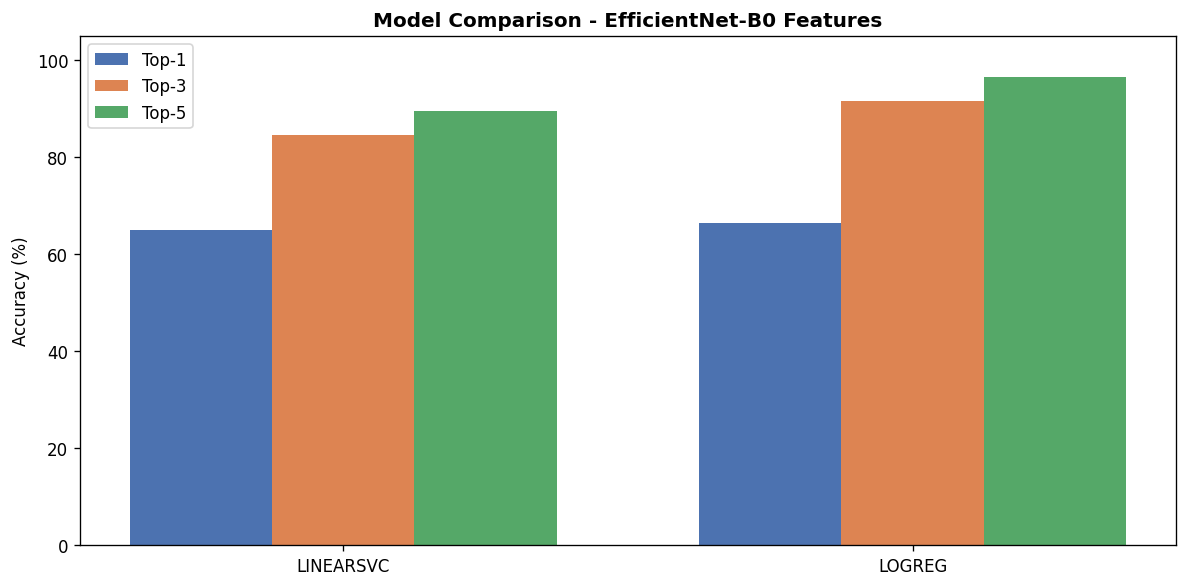

In [9]:
# Comparison chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(models))
width = 0.25

top1_vals = [results[m]['top1']*100 for m in models]
top3_vals = [results[m]['top3']*100 for m in models]
top5_vals = [results[m]['top5']*100 for m in models]

ax.bar(x - width, top1_vals, width, label='Top-1', color=PALETTE[0])
ax.bar(x, top3_vals, width, label='Top-3', color=PALETTE[1])
ax.bar(x + width, top5_vals, width, label='Top-5', color=PALETTE[2])

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in models])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison - EfficientNet-B0 Features', fontweight='bold')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

In [10]:
# Summary table
rows = []
for name in models:
    rows.append({
        'Model': name.upper(),
        'Top-1 (%)': round(results[name]['top1']*100, 2),
        'Top-3 (%)': round(results[name]['top3']*100, 2),
        'Top-5 (%)': round(results[name]['top5']*100, 2),
        'CV Mean (%)': round(cv_results[name].mean()*100, 2),
        'CV Std (%)': round(cv_results[name].std()*100, 2),
        'Train Time (s)': round(train_times[name], 1)
    })

df = pd.DataFrame(rows).set_index('Model')
display(df.style.highlight_max(subset=['Top-1 (%)', 'Top-3 (%)', 'CV Mean (%)'], color='#c6efce'))

BEST = max(results, key=lambda x: results[x]['top1'])
print(f'\nBest: {BEST.upper()} ({results[BEST]["top1"]*100:.2f}%)')

,Top-1 (%),Top-3 (%),Top-5 (%),CV Mean (%),CV Std (%),Train Time (s)
Model,,,,,,
LINEARSVC,65.000000,84.500000,89.500000,63.250000,3.880000,17.000000
LOGREG,66.500000,91.500000,96.500000,67.250000,2.970000,0.600000



Best: LOGREG (66.50%)


## 8. Save Artifacts

In [11]:
for name, m in models.items():
    out_dir = os.path.join(ARTIFACTS_PATH, name)
    os.makedirs(out_dir, exist_ok=True)

    joblib.dump(scaler, os.path.join(out_dir, 'scaler.pkl'))
    joblib.dump(m, os.path.join(out_dir, 'model.pkl'))
    joblib.dump(label_names, os.path.join(out_dir, 'label_names.pkl'))
    if name in best_params:
        joblib.dump(best_params[name], os.path.join(out_dir, 'best_params.pkl'))

    print(f'Saved: {out_dir}')

print('\nAll models saved!')

Saved: /content/drive/MyDrive/Miniproject/src/models/artifacts/linearsvc
Saved: /content/drive/MyDrive/Miniproject/src/models/artifacts/logreg

All models saved!


## 9. Best Model Evaluation

In [12]:
# Classification report for best model
y_pred = results[BEST]['y_pred']
target_names = label_names[np.unique(y_test).astype(int)]
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

                                  precision    recall  f1-score   support

              Bungarus_caeruleus       0.76      0.80      0.78        20
    Craspedocephalus_malabaricus       0.80      0.80      0.80        20
Craspedocephalus_trigonocephalus       0.86      0.95      0.90        20
                 Fowlea_piscator       0.56      0.50      0.53        20
                 Hypnale_hypnale       0.79      0.75      0.77        20
                    Hypnale_zara       0.85      0.85      0.85        20
               Lycodon_capucinus       0.54      0.75      0.62        20
                       Naja_naja       0.50      0.45      0.47        20
              Ophiophagus_hannah       0.52      0.60      0.56        20
                    Ptyas_mucosa       0.36      0.20      0.26        20

                        accuracy                           0.67       200
                       macro avg       0.65      0.66      0.65       200
                    weighted avg    

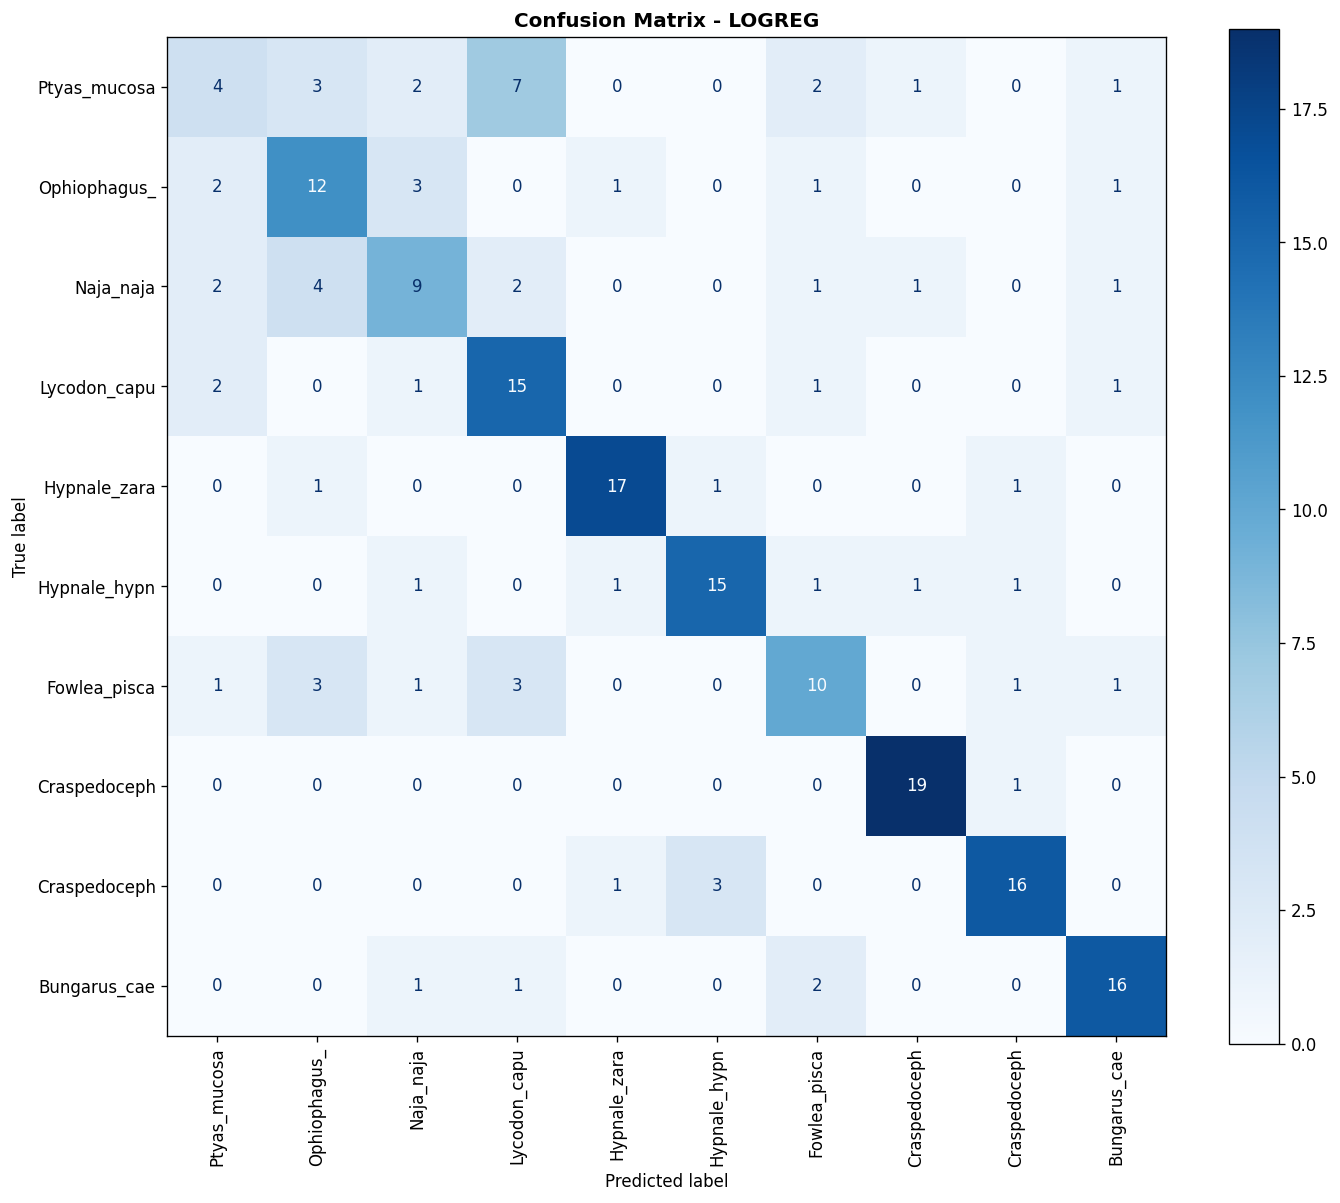

In [13]:
# Confusion matrix
N = min(15, len(np.unique(y_test)))
counts = np.bincount(y_test.astype(int))
top_ids = np.argsort(counts)[::-1][:N]
mask = np.isin(y_test, top_ids)

cm = confusion_matrix(y_test[mask], y_pred[mask], labels=top_ids)
cm_labels = [label_names[i][:12] for i in top_ids]

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm, display_labels=cm_labels).plot(ax=ax, cmap='Blues', xticks_rotation=90)
ax.set_title(f'Confusion Matrix - {BEST.upper()}', fontweight='bold')
plt.tight_layout()
plt.show()